# Project 2: COVID-19 Global Data Analysis

**Author:** Karuna Gehani
**Dataset:** COVID-19 Country-wise Latest Data (Kaggle)
**Tools:** Python, Pandas, Matplotlib, Seaborn

## Objective
Analyze global COVID-19 data to identify the most affected countries,
death rates, recovery rates, and correlations between key metrics.

## Key Questions
1. Which countries have the most confirmed cases?
2. Which countries have the highest death rates?
3. Which countries have the best recovery rates?
4. How do COVID metrics correlate with each other?

In [2]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

df = pd.read_csv('data/country_wise_latest.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.isnull().sum())
print(df.describe())

(187, 15)
['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.

c:\Users\karun\Desktop\da\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\Users\karun\AppData\Local\Temp\ipykernel_21884\3502256357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=top_confirmed, palette='Reds_d')


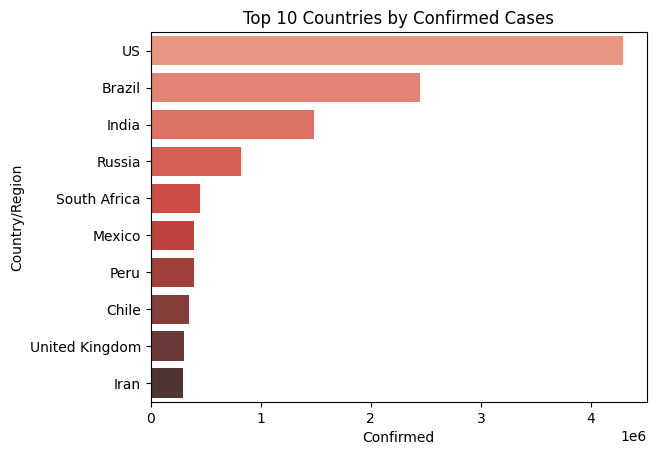

In [3]:
# Top 10 countries by confirmed cases
top_confirmed = df.nlargest(10, 'Confirmed')[['Country/Region', 'Confirmed']]
sns.barplot(x='Confirmed', y='Country/Region', data=top_confirmed, palette='Reds_d')
plt.title('Top 10 Countries by Confirmed Cases')
plt.savefig('charts/chart1_top_confirmed.png')
plt.show()

C:\Users\karun\AppData\Local\Temp\ipykernel_21884\2496966339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deaths', y='Country/Region', data=top_deaths, palette='Greys_d')


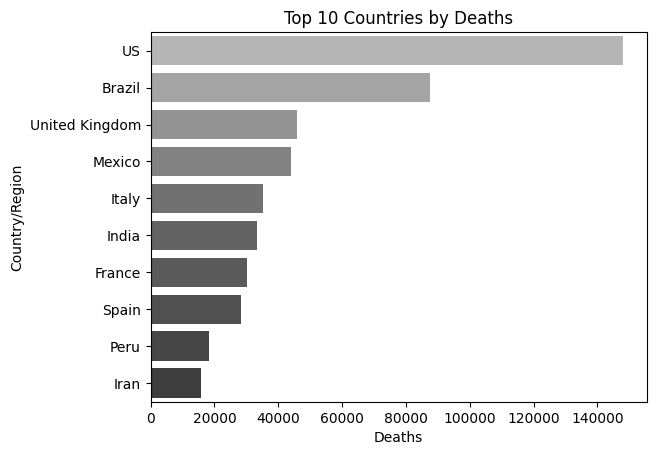

In [4]:
# Top 10 countries by deaths
top_deaths = df.nlargest(10, 'Deaths')[['Country/Region', 'Deaths']]
sns.barplot(x='Deaths', y='Country/Region', data=top_deaths, palette='Greys_d')
plt.title('Top 10 Countries by Deaths')
plt.savefig('charts/chart2_top_deaths.png')
plt.show()

C:\Users\karun\AppData\Local\Temp\ipykernel_21884\4196585311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Death Rate %', y='Country/Region', data=top_death_rate, palette='Purples_d')


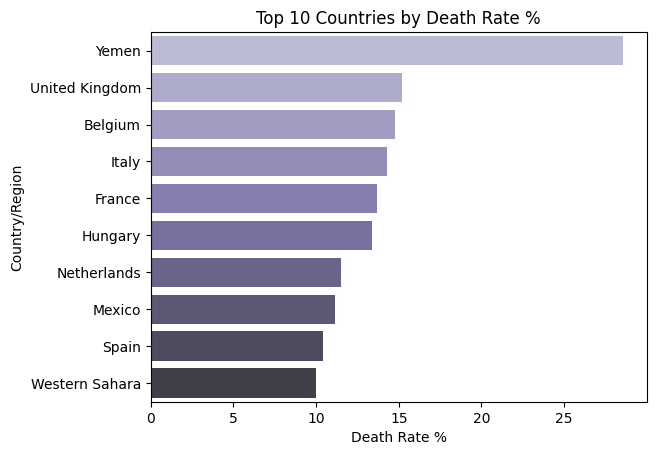

In [5]:
# Death rate by country (Deaths / Confirmed * 100)
df['Death Rate %'] = (df['Deaths'] / df['Confirmed'] * 100).round(2)
top_death_rate = df.nlargest(10, 'Death Rate %')[['Country/Region', 'Death Rate %']]
sns.barplot(x='Death Rate %', y='Country/Region', data=top_death_rate, palette='Purples_d')
plt.title('Top 10 Countries by Death Rate %')
plt.savefig('charts/chart3_death_rate.png')
plt.show()

C:\Users\karun\AppData\Local\Temp\ipykernel_21884\3111795923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovery Rate %', y='Country/Region', data=top_recovery, palette='Greens_d')


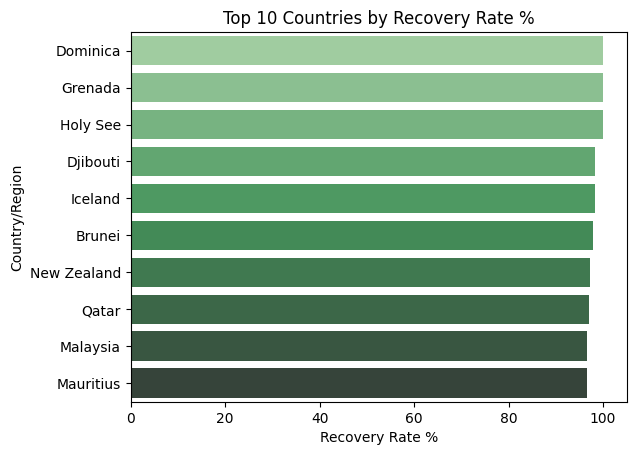

In [6]:
# Recovery rate
df['Recovery Rate %'] = (df['Recovered'] / df['Confirmed'] * 100).round(2)
top_recovery = df.nlargest(10, 'Recovery Rate %')[['Country/Region', 'Recovery Rate %']]
sns.barplot(x='Recovery Rate %', y='Country/Region', data=top_recovery, palette='Greens_d')
plt.title('Top 10 Countries by Recovery Rate %')
plt.savefig('charts/chart4_recovery_rate.png')
plt.show()

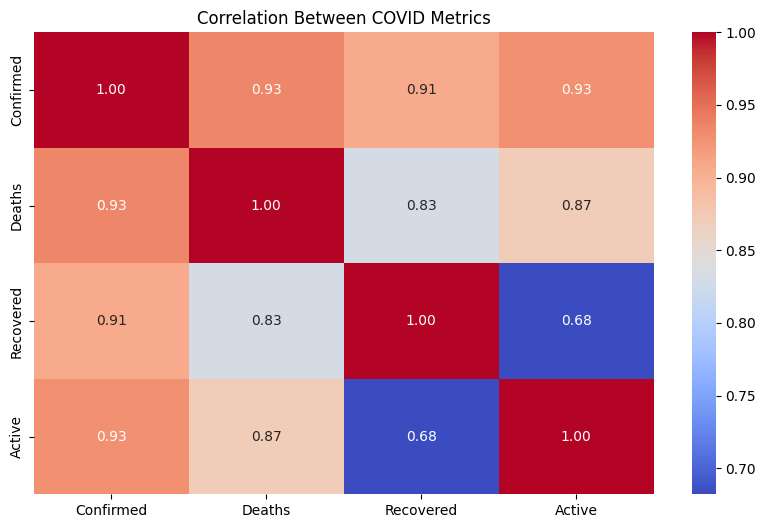

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between COVID Metrics')
plt.savefig('charts/chart5_correlation.png')
plt.show()